In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

## Loading & processing data

In [2]:
# Selecting the brain region
select_region = "Isocortex-1"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Count the number of cells in each class
class_counts = adata.obs["class"].value_counts()
print(class_counts)

class
01 IT-ET Glut        121827
02 NP-CT-L6b Glut     57507
07 CTX-MGE GABA       13401
06 CTX-CGE GABA       12688
31 OPC-Oligo           6465
30 Astro-Epen          6372
33 Vascular            4813
34 Immune              3607
08 CNU-MGE GABA         432
05 OB-IMN GABA          213
03 OB-CR Glut            89
04 DG-IMN Glut           52
09 CNU-LGE GABA          43
32 OEC                   36
11 CNU-HYa GABA          31
12 HY GABA               30
14 HY Glut               25
25 Pineal Glut           19
13 CNU-HYa Glut           8
16 HY MM Glut             7
24 MY Glut                2
10 LSX GABA               1
15 HY Gnrh1 Glut          1
27 MY GABA                1
Name: count, dtype: int64


In [5]:
# Identify classes with few cells
n_cells_threshold = 100

# Filter out the cells belonging to the identified classes
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
adata = adata[~adata.obs["class"].isin(classes_to_remove)].copy()

print(f"Classes with less than {n_cells_threshold} cells ({classes_to_remove}) have been removed.")
adata

Classes with less than 100 cells (['03 OB-CR Glut', '04 DG-IMN Glut', '09 CNU-LGE GABA', '32 OEC', '11 CNU-HYa GABA', '12 HY GABA', '14 HY Glut', '25 Pineal Glut', '13 CNU-HYa Glut', '16 HY MM Glut', '24 MY Glut', '10 LSX GABA', '15 HY Gnrh1 Glut', '27 MY GABA']) have been removed.


AnnData object with n_obs × n_vars = 227325 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [6]:
gene_names_df = adata.var.copy()
adata.var.set_index("gene_symbol", inplace=True)

In [7]:
# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)  # Select highly variable genes

### DE

In [8]:
# Perform differential expression analysis
group_by="class"
sc.tl.rank_genes_groups(
    adata,
    groupby=group_by,
    method="wilcoxon",
    use_raw=False
)

In [9]:
# Extract the differential expression results
deg_results = pd.DataFrame({
    group: pd.DataFrame(adata.uns["rank_genes_groups"]["names"])[group]
    for group in adata.uns["rank_genes_groups"]["names"].dtype.names
})

# # Save the dataframe to a CSV file
# output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
# deg_results.to_csv(output_path, index=False)

# print(f"Differentially expressed genes saved to {output_path}")

In [10]:
deg_results.head()

,01 IT-ET Glut,02 NP-CT-L6b Glut,05 OB-IMN GABA,06 CTX-CGE GABA,07 CTX-MGE GABA,08 CNU-MGE GABA,30 Astro-Epen,31 OPC-Oligo,33 Vascular,34 Immune
0,C1ql3,Hs3st4,H3f3b,Adarb2,Kcnc2,Sox2ot,Plpp3,Olig1,Sparc,Laptm5
1,Cck,Cdh18,Zbtb20,Dlx6os1,Rab3b,Alk,Slc1a3,Qk,Utrn,Inpp5d
2,Tafa1,Foxp2,Msi2,Gad1,Slc32a1,Nkain3,Slc1a2,Gjc3,Zbtb20,Cst3
3,Bdnf,Nxph3,Sox4,Erbb4,Nxph1,Crhbp,Mt1,Sox10,Epas1,Serinc3
4,Nrgn,Rprm,Ttc28,Zfp536,Grip1,Npy,Gja1,Bcas1,Gng5,Csf1r


## Subsampling and Bootstrapping

In [ ]:
from joblib import Parallel, delayed
from collections import defaultdict
import scipy
import anndata
import gc

In [ ]:
def _process_iteration( # Renamed to indicate it's an internal helper
    iteration_idx: int,
    adata_full_X: np.ndarray | scipy.sparse.spmatrix, # Pass .X directly
    adata_full_obs: pd.DataFrame,                     # Pass .obs DataFrame
    adata_full_var_names: pd.Index,                 # Pass .var_names
    all_obs_indices: pd.Index,                      # Original .obs.index for consistent indexing
    cluster_key: str,
    groupby_val: str, # The specific cluster/group value to find markers for
    subsample_fraction: float,
    rank_genes_groups_params: dict,
    n_total_iterations: int, # For logging
    original_cluster_categories: pd.CategoricalDtype # To maintain category consistency
) -> tuple | None:
    """
    Internal worker function for a single subsampling iteration.
    Optimized for memory by working with components of AnnData.
    """
    # print(f"Starting iteration {iteration_idx + 1}/{n_total_iterations}") # Can be verbose for 1000s

    # --- 1. Subsample cell indices (these are original index LABELS) ---
    subsampled_obs_label_list = [] # Stores the string/integer labels from original .obs.index

    # Subsample the target group
    group_cells_mask = (adata_full_obs[cluster_key] == groupby_val)
    group_cells_original_labels = all_obs_indices[group_cells_mask]
    
    n_group_cells_to_sample = int(len(group_cells_original_labels) * subsample_fraction)
    if n_group_cells_to_sample > 0:
        subsampled_group_labels = np.random.choice(
            group_cells_original_labels, size=n_group_cells_to_sample, replace=False
        )
        subsampled_obs_label_list.extend(subsampled_group_labels)

    # Subsample the 'rest' groups proportionally
    other_cluster_values = [c for c in original_cluster_categories.categories if c != groupby_val]
    for other_cluster_val in other_cluster_values:
        other_cluster_cells_mask = (adata_full_obs[cluster_key] == other_cluster_val)
        other_cluster_original_labels = all_obs_indices[other_cluster_cells_mask]
        
        n_other_cells_to_sample = int(len(other_cluster_original_labels) * subsample_fraction)
        if n_other_cells_to_sample > 0:
            subsampled_other_cluster_labels = np.random.choice(
                other_cluster_original_labels, size=n_other_cells_to_sample, replace=False
            )
            subsampled_obs_label_list.extend(subsampled_other_cluster_labels)
    
    if not subsampled_obs_label_list:
        # This print can be very verbose, consider logging or less frequent printing
        # print(f"Warning: No cells selected in iteration {iteration_idx + 1} for group {groupby_val}. Skipping.")
        return None

    # --- 2. Create a minimal AnnData object for the subsample ---
    
    # Create a boolean mask aligned with the original adata_full_X rows
    # pd.Series(all_obs_indices) creates a Series with all_obs_indices as values, indexed 0..N-1
    # .isin() checks if these values are in subsampled_obs_label_list
    # The result is a boolean Series, indexed 0..N-1, aligning with rows of adata_full_X
    positional_boolean_mask_series = pd.Series(all_obs_indices.to_numpy()).isin(subsampled_obs_label_list)
    positional_boolean_mask_numpy = positional_boolean_mask_series.to_numpy()
    
    # Slice .X using the NumPy boolean mask
    X_sub = adata_full_X[positional_boolean_mask_numpy, :]
    
    # Slice .obs using the collected labels. This ensures correct cell selection.
    # It's important that subsampled_obs_label_list contains unique labels for .loc to work as expected here.
    # np.random.choice ensures this if drawn from unique indices.
    obs_sub = adata_full_obs.loc[list(dict.fromkeys(subsampled_obs_label_list)), [cluster_key]].copy() # list(dict.fromkeys()) to ensure uniqueness if lists were concatenated poorly
    obs_sub[cluster_key] = pd.Categorical(obs_sub[cluster_key], categories=original_cluster_categories.categories)

    # Create minimal var DataFrame
    var_sub = pd.DataFrame(index=adata_full_var_names)

    adata_sub = anndata.AnnData(X=X_sub, obs=obs_sub, var=var_sub)

    # --- 3. Check cell counts in subsample ---
    group_cell_count = np.sum(adata_sub.obs[cluster_key] == groupby_val)
    rest_cell_count = len(adata_sub.obs) - group_cell_count

    min_cells_for_deg = 3 # Scanpy usually needs at least this many
    if group_cell_count < min_cells_for_deg:
        # print(f"Warning: Group '{groupby_val}' has {group_cell_count} cells after subsampling in iter {iteration_idx + 1}. Skipping DEG.")
        del adata_sub, X_sub, obs_sub, var_sub 
        return None
    if rest_cell_count < min_cells_for_deg : 
        # print(f"Warning: 'Rest' group has {rest_cell_count} cells after subsampling in iter {iteration_idx + 1}. Skipping DEG.")
        del adata_sub, X_sub, obs_sub, var_sub 
        return None

    # --- 4. Run DEG analysis ---
    try:
        # Filter out any NaN genes that might have been introduced if adata_sub.var_names had issues (unlikely with current setup)
        valid_genes_mask = adata_sub.var_names.notna()
        if not valid_genes_mask.all():
            adata_sub = adata_sub[:, valid_genes_mask].copy()

        if adata_sub.shape[1] == 0: # No genes left
            # print(f"Warning: No valid genes in subsample for iteration {iteration_idx + 1}. Skipping DEG.")
            del adata_sub, X_sub, obs_sub, var_sub
            return None
            
        sc.tl.rank_genes_groups(adata_sub, groupby=cluster_key, groups=[groupby_val], **rank_genes_groups_params)
    except Exception as e:
        # print(f"Error during rank_genes_groups in iteration {iteration_idx + 1} for group {groupby_val}: {e}")
        del adata_sub, X_sub, obs_sub, var_sub
        return None
        
    # --- 5. Extract results ---
    group_str = str(groupby_val) 
    
    rgg_results = adata_sub.uns.get('rank_genes_groups', {})
    if 'names' not in rgg_results or \
       group_str not in rgg_results['names'].dtype.names:
        # print(f"Warning: DEG results for group '{group_str}' not found in iteration {iteration_idx + 1}. Skipping.")
        del adata_sub, X_sub, obs_sub, var_sub
        return None

    # Ensure all expected metric arrays exist for the group
    required_metrics = ['names', 'logfoldchanges', 'pvals_adj', 'scores']
    metrics_present = all(
        group_str in rgg_results.get(metric, {}).dtype.names 
        for metric in required_metrics if isinstance(rgg_results.get(metric), np.ndarray)
    )
    if not metrics_present and not all(group_str in rgg_results.get(metric, {}) for metric in required_metrics if not isinstance(rgg_results.get(metric), np.ndarray)): # Fallback for older scanpy?
         # print(f"Warning: Not all required DEG metrics found for group '{group_str}' in iteration {iteration_idx + 1}. Skipping.")
         del adata_sub, X_sub, obs_sub, var_sub
         return None


    degs_df = pd.DataFrame({
        metric_name: rgg_results[metric_name][group_str]
        for metric_name in required_metrics
    })
    
    degs_df = degs_df.dropna(subset=['names']) # Ensure gene names are not NaN
    # Filter out rows where critical numerical metrics might be NaN, if any
    degs_df = degs_df.dropna(subset=['logfoldchanges', 'pvals_adj', 'scores'])


    iteration_genes = degs_df['names'].tolist()
    iteration_metrics = {
        gene: {
            'logfoldchanges': lfc, 'pvals_adj': pval, 'scores': score
        } for gene, lfc, pval, score in zip(
            degs_df['names'], degs_df['logfoldchanges'], degs_df['pvals_adj'], degs_df['scores']
        ) # NaNs already dropped from degs_df
    }
    
    # --- 6. Cleanup ---
    del adata_sub, X_sub, obs_sub, var_sub, degs_df, rgg_results
    # gc.collect() # Uncomment only if severe memory issues per worker persist

    return iteration_genes, iteration_metrics

In [13]:
def run_robustness_analysis_optimized(
    adata_full: anndata.AnnData,
    cluster_key: str,
    groupby_val: str, # The specific cluster label for which to find markers
    subsample_fraction: float = 0.8,
    n_iterations: int = 100, # Increased default, user wants 1000
    n_jobs: int = -1,
    rank_genes_groups_params: dict = None
) -> pd.DataFrame:
    """
    Performs DEG analysis on multiple subsamples of an AnnData object to assess robustness.
    Optimized for memory usage.

    Args:
        adata_full: The full AnnData object.
        cluster_key: The key in adata_full.obs that contains the cluster labels.
        groupby_val: The specific cluster label (e.g., 'ClusterA', '3') for which to find DEGs.
        subsample_fraction: Fraction of cells to sample from the target group and proportionally from other groups.
        n_iterations: Number of subsampling iterations.
        n_jobs: Number of parallel jobs for Joblib.
        rank_genes_groups_params: Dictionary of parameters for sc.tl.rank_genes_groups.
                                  Example: {'method': 'wilcoxon', 'n_genes': 200}

    Returns:
        A DataFrame summarizing DEG robustness.
    """
    if rank_genes_groups_params is None:
        rank_genes_groups_params = {'method': 'wilcoxon', 'n_genes': 200, 'pts': True}
    
    # Ensure cluster_key column is categorical for proper handling of all groups
    if not pd.api.types.is_categorical_dtype(adata_full.obs[cluster_key]):
        adata_full.obs[cluster_key] = adata_full.obs[cluster_key].astype('category')
    original_cluster_categories = adata_full.obs[cluster_key].dtype

    if str(groupby_val) not in original_cluster_categories.categories.astype(str): # Compare as string due to scanpy's keying
        raise ValueError(f"Group '{groupby_val}' not found in adata_full.obs['{cluster_key}']. "
                         f"Available groups: {original_cluster_categories.categories.tolist()}")

    # Extract components of AnnData to pass to workers
    # This can help with joblib serialization and memory management, especially for .X
    adata_full_X = adata_full.X
    adata_full_obs = adata_full.obs # This will be passed by joblib, sliced inside worker
    adata_full_var_names = adata_full.var_names.copy() # Ensure it's a standalone object
    all_obs_indices = adata_full.obs.index.copy()


    # Run iterations in parallel
    # adata_full is not copied for each job here. Joblib handles its availability to workers.
    # The _process_iteration function is designed to be as stateless as possible with its inputs.
    results = Parallel(n_jobs=n_jobs, backend="loky")( # "loky" is often more robust
        delayed(_process_iteration)(
            i,
            adata_full_X,
            adata_full_obs,
            adata_full_var_names,
            all_obs_indices,
            cluster_key,
            groupby_val,
            subsample_fraction,
            rank_genes_groups_params,
            n_iterations,
            original_cluster_categories
        ) for i in range(n_iterations)
    )

    # Aggregate results
    all_gene_metrics = defaultdict(lambda: {
        'logfoldchanges': [], 'pvals_adj': [], 'scores': [], 'count': 0
    })
    valid_iterations_count = 0

    for res_tuple in results:
        if res_tuple is not None:
            valid_iterations_count += 1
            iteration_genes, iteration_metrics_dict = res_tuple
            for gene, metrics in iteration_metrics_dict.items():
                all_gene_metrics[gene]['logfoldchanges'].append(metrics['logfoldchanges'])
                all_gene_metrics[gene]['pvals_adj'].append(metrics['pvals_adj'])
                all_gene_metrics[gene]['scores'].append(metrics['scores'])
                all_gene_metrics[gene]['count'] += 1
    
    if not all_gene_metrics:
        print(f"Warning: No DEGs found across any of the {valid_iterations_count} valid iterations for group {groupby_val}. Returning empty DataFrame.")
        return pd.DataFrame()

    summary_data = []
    for gene, metrics_data in all_gene_metrics.items():
        count = metrics_data['count']
        frequency = count / valid_iterations_count if valid_iterations_count > 0 else 0
        
        summary_data.append({
            'gene': gene,
            'frequency': frequency,
            'iterations_found': count,
            'mean_log2fc': np.mean(metrics_data['logfoldchanges']) if metrics_data['logfoldchanges'] else np.nan,
            'median_log2fc': np.median(metrics_data['logfoldchanges']) if metrics_data['logfoldchanges'] else np.nan,
            'std_log2fc': np.std(metrics_data['logfoldchanges']) if metrics_data['logfoldchanges'] else np.nan,
            'mean_pval_adj': np.mean(metrics_data['pvals_adj']) if metrics_data['pvals_adj'] else np.nan,
            'median_pval_adj': np.median(metrics_data['pvals_adj']) if metrics_data['pvals_adj'] else np.nan,
            'mean_score': np.mean(metrics_data['scores']) if metrics_data['scores'] else np.nan
        })

    robust_degs_df = pd.DataFrame(summary_data)
    robust_degs_df = robust_degs_df.sort_values(
        by=['frequency', 'iterations_found', 'mean_score'], ascending=[False, False, False]
    )

    print(f"Completed {valid_iterations_count} valid iterations out of {n_iterations} for group {groupby_val}.")
    return robust_degs_df

In [39]:
# Specify the cluster/group you are interested in
target_cluster_id = "06 CTX-CGE GABA"
n_genes = 100
n_iterations = 100

# Ensure the cluster key is categorical
cluster_column = 'class' # Or your specific cluster column name
if not pd.api.types.is_categorical_dtype(adata.obs[cluster_column]):
    adata.obs[cluster_column] = adata.obs[cluster_column].astype('category')

# Define parameters for rank_genes_groups
deg_params = {
    'method': 'wilcoxon', 
    'n_genes': n_genes, # Number of top genes to consider from each subsample's DEG run
    'pts': True     # Compute fraction of cells expressing gene (useful for context)
    # Add other params like 'use_raw=False' if applicable
}

# --- Check if target_cluster_id exists ---
if str(target_cluster_id) not in adata.obs[cluster_column].cat.categories.astype(str):
    print(f"Error: Target cluster '{target_cluster_id}' not found in adata.obs['{cluster_column}'].")
    print(f"Available clusters: {adata.obs[cluster_column].cat.categories.tolist()}")
else:
    print(f"Running optimized robustness analysis for cluster: {target_cluster_id}")
    robustness_results_df_optimized = run_robustness_analysis_optimized(
        adata_full=adata, # Pass your main (or region-filtered) AnnData object
        cluster_key=cluster_column,
        groupby_val=target_cluster_id, 
        subsample_fraction=0.8,
        n_iterations=n_iterations,
        n_jobs=-1,
        rank_genes_groups_params=deg_params
    )

    if not robustness_results_df_optimized.empty:
        print("\nTop robust DEGs (optimized):")
        print(robustness_results_df_optimized.head())
        # robustness_results_df_optimized.to_csv(f'robust_degs_optimized_cluster_{target_cluster_id}_1000iter.csv', index=False)
    else:
        print(f"No robust DEGs found for cluster {target_cluster_id} with optimized function.")

Running optimized robustness analysis for cluster: 06 CTX-CGE GABA


/tmp/ipykernel_846504/4227000023.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata.obs[cluster_column]):
/tmp/ipykernel_846504/3989408456.py:31: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_full.obs[cluster_key]):


Completed 100 valid iterations out of 100 for group 06 CTX-CGE GABA.

Top robust DEGs (optimized):
       gene  frequency  iterations_found  mean_log2fc  median_log2fc  \
0     C1ql3        1.0               100     2.810223       2.810494   
1   Galnt14        1.0               100     2.460869       2.460979   
2     Tenm3        1.0               100     1.931574       1.931988   
3  Il1rapl2        1.0               100     2.667791       2.667488   
4       Cck        1.0               100     1.616707       1.616998   

   std_log2fc  mean_pval_adj  median_pval_adj  mean_score  
0    0.009451            0.0              0.0  120.208440  
1    0.009300            0.0              0.0  106.893010  
2    0.009916            0.0              0.0  100.440737  
3    0.018611            0.0              0.0   96.406870  
4    0.004620            0.0              0.0   91.741678  


### Visualization

In [31]:
def plot_frequency_vs_mean_score(
    robust_df: pd.DataFrame,
    target_info: str,
    highlight_top_n: int = 10,
    label_genes: bool = True,
    ax=None # Optional Matplotlib Axes object
):
    """
    Scatter plot of DEG frequency vs. mean DEG score.

    Args:
        robust_df: DataFrame from run_robustness_analysis_optimized.
        target_info: String describing the target group for the plot title.
        highlight_top_n: Number of top genes (by frequency then score) to label.
        label_genes: Whether to label genes.
        ax: Optional Matplotlib Axes to plot on.
    """
    if robust_df.empty:
        print(f"Robustness DataFrame for {target_info} is empty. Skipping Freq vs Mean Score plot.")
        return
    if 'mean_score' not in robust_df.columns:
        print(f"'mean_score' column not found in DataFrame for {target_info}. Skipping plot.")
        return

    if ax is None:
        fig, current_ax = plt.subplots(figsize=(12, 8))
    else:
        current_ax = ax

    scatter = sns.scatterplot(
        data=robust_df,
        x='mean_score',
        y='frequency',
        hue='mean_log2fc', # Color by effect size
        size='iterations_found',
        sizes=(20, 250),
        palette="coolwarm", # LFC: blue (down) to red (up)
        alpha=0.7,
        ax=current_ax
    )
    current_ax.set_xlabel("Mean DEG Score (e.g., Wilcoxon U, t-statistic)")
    current_ax.set_ylabel("Frequency as DEG")
    current_ax.set_title(f"Frequency vs. Mean DEG Score for {target_info}")

    current_ax.legend(title='Mean Log2FC', bbox_to_anchor=(1.05, 1), loc='upper left')
    current_ax.grid(True, linestyle='--', alpha=0.5)

    # Label top N genes
    if label_genes and highlight_top_n > 0:
        highlight_df = robust_df.sort_values(
            by=['frequency', 'mean_score'], ascending=[False, False]
        ).head(highlight_top_n)
        
        for i, row in highlight_df.iterrows():
            current_ax.text(row['mean_score'], row['frequency'] - 0.03, row['gene'], fontsize=9, ha='left') # Adjust offset based on xlim, + 0.01 * current_ax.get_xlim()[1]

    if ax is None:
        plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust for legend
        plt.show()

    print(f"\nInterpretation for {target_info} Frequency vs. Mean Score Scatter Plot:")
    print("- Shows relationship between consistency (frequency) and raw statistical score from DEG tests.")
    print("- Ideal genes are in the top-right (high frequency, high score).")
    print("- Color indicates average Log2FC, helping distinguish up/down-regulated robust genes.")

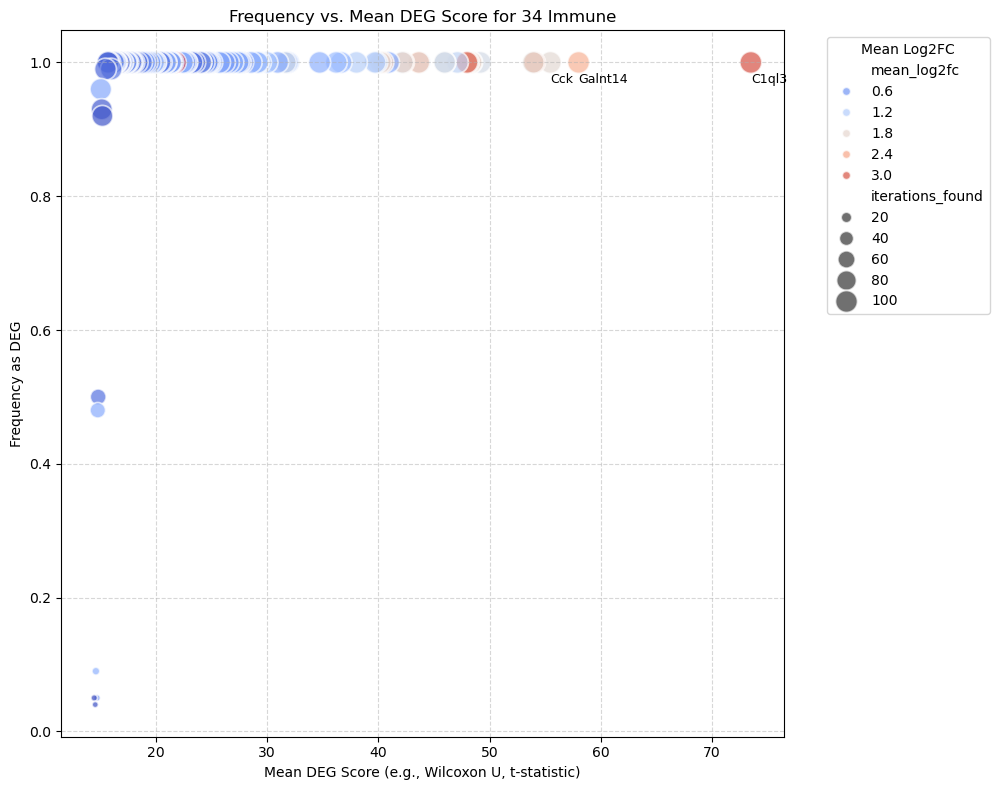


Interpretation for 34 Immune Frequency vs. Mean Score Scatter Plot:
- Shows relationship between consistency (frequency) and raw statistical score from DEG tests.
- Ideal genes are in the top-right (high frequency, high score).
- Color indicates average Log2FC, helping distinguish up/down-regulated robust genes.


In [34]:
plot_frequency_vs_mean_score(robustness_results_df_optimized,
                             target_info="34 Immune",
                             highlight_top_n=3)

## No parallel

In [40]:
def run_subsampled_deg(
    adata_full: anndata.AnnData,
    cluster_key: str,
    groupby: str, # The cluster (or group) for which to find markers
    subsample_fraction: float = 0.8,
    n_iterations: int = 50,
    n_jobs: int = -1, # Use all available cores, set to 1 for no parallelization
    rank_genes_groups_params: dict = None # Parameters for sc.tl.rank_genes_groups
) -> pd.DataFrame:
    """
    Performs DEG analysis on multiple subsamples of an AnnData object to assess robustness.
    (Original simpler version)

    Args:
        adata_full: The full AnnData object.
        cluster_key: The key in adata_full.obs that contains the cluster labels.
        groupby: The specific cluster label (from adata_full.obs[cluster_key]) for which to find DEGs.
                 It's case-sensitive and must match a category in adata_full.obs[cluster_key].
        subsample_fraction: Fraction of cells to sample from each cluster.
        n_iterations: Number of subsampling iterations.
        n_jobs: Number of parallel jobs for Joblib.
        rank_genes_groups_params: Dictionary of parameters to pass to
                                  sc.tl.rank_genes_groups.
                                  Example: {'method': 'wilcoxon', 'pts': True, 'n_genes': 200}

    Returns:
        A DataFrame where rows are genes and columns indicate their frequency
        as DEGs, mean log2foldchange, mean pval_adj, mean_score, etc., across iterations.
    """
    if rank_genes_groups_params is None:
        rank_genes_groups_params = {'method': 'wilcoxon', 'n_genes': 200, 'pts': True}

    # Ensure the cluster_key column is categorical and 'groupby' exists
    if not pd.api.types.is_categorical_dtype(adata_full.obs[cluster_key]):
        adata_full.obs[cluster_key] = adata_full.obs[cluster_key].astype('category')
    
    # Convert groupby to string if it's not, as Scanpy uses string keys in .uns
    groupby_str_check = str(groupby)
    if groupby_str_check not in adata_full.obs[cluster_key].cat.categories.astype(str):
        raise ValueError(
            f"Group '{groupby}' (as string '{groupby_str_check}') not found in adata_full.obs['{cluster_key}']. "
            f"Available groups: {adata_full.obs[cluster_key].cat.categories.tolist()}"
        )

    # This internal function will be run in parallel for each iteration
    def process_iteration(iteration_idx: int, adata_iteration_copy: anndata.AnnData) -> tuple | None:
        print(f"Starting iteration {iteration_idx + 1}/{n_iterations}")
        
        obs_df = adata_iteration_copy.obs.copy()
        subsampled_indices_list = [] # List to store original index labels of subsampled cells

        # Subsample the target 'groupby' group
        group_cells_labels = obs_df[obs_df[cluster_key] == groupby].index
        n_group_cells_to_sample = int(len(group_cells_labels) * subsample_fraction)
        if n_group_cells_to_sample > 0:
            subsampled_group_labels = np.random.choice(
                group_cells_labels, size=n_group_cells_to_sample, replace=False
            )
            subsampled_indices_list.extend(subsampled_group_labels)

        # Subsample the 'rest' groups (proportionally from each other cluster)
        other_clusters = [c for c in obs_df[cluster_key].cat.categories if c != groupby]
        for other_cluster in other_clusters:
            other_cluster_cells_labels = obs_df[obs_df[cluster_key] == other_cluster].index
            n_other_cells_to_sample = int(len(other_cluster_cells_labels) * subsample_fraction)
            if n_other_cells_to_sample > 0:
                subsampled_other_cluster_labels = np.random.choice(
                    other_cluster_cells_labels, size=n_other_cells_to_sample, replace=False
                )
                subsampled_indices_list.extend(subsampled_other_cluster_labels)
        
        if not subsampled_indices_list:
            print(f"Warning: No cells selected in iteration {iteration_idx + 1} for group {groupby}. Skipping.")
            return None

        # Create a new AnnData object for the subsample using original labels
        adata_sub = adata_iteration_copy[subsampled_indices_list, :].copy()

        # Ensure the cluster_key column still has the necessary categories
        original_categories = adata_iteration_copy.obs[cluster_key].cat.categories
        adata_sub.obs[cluster_key] = pd.Categorical(adata_sub.obs[cluster_key], categories=original_categories)

        # Check cell counts
        min_cells_for_deg = 3
        if adata_sub.obs[cluster_key].value_counts().get(groupby, 0) < min_cells_for_deg:
            print(f"Warning: Group '{groupby}' has < {min_cells_for_deg} cells after subsampling in iteration {iteration_idx + 1}. Skipping DEG.")
            return None
        if len(adata_sub.obs[adata_sub.obs[cluster_key] != groupby]) < min_cells_for_deg:
            print(f"Warning: 'Rest' group has < {min_cells_for_deg} cells after subsampling in iteration {iteration_idx + 1}. Skipping DEG.")
            return None

        # Run DEG analysis on the subsample
        # rank_genes_groups compares `groupby` vs. `rest` by default when `groups=[groupby]`
        sc.tl.rank_genes_groups(adata_sub, groupby=cluster_key, groups=[str(groupby)], **rank_genes_groups_params)

        # Extract results for the specified group (Scanpy uses string keys for groups in .uns)
        group_key_in_uns = str(groupby)
        
        rgg_results = adata_sub.uns.get('rank_genes_groups', {})
        if 'names' not in rgg_results or group_key_in_uns not in rgg_results['names'].dtype.names:
            print(f"Warning: DEG results for group '{group_key_in_uns}' not found in iteration {iteration_idx + 1}. Skipping.")
            return None

        # Ensure all required fields are present for the group
        required_fields = ['names', 'logfoldchanges', 'pvals_adj', 'scores']
        current_degs_data = {}
        for field in required_fields:
            if field not in rgg_results or group_key_in_uns not in rgg_results[field].dtype.names:
                 print(f"Warning: Metric '{field}' for group '{group_key_in_uns}' not found in iteration {iteration_idx + 1}. Skipping.")
                 return None
            current_degs_data[field] = rgg_results[field][group_key_in_uns]
        
        degs_df = pd.DataFrame(current_degs_data)
        degs_df = degs_df.dropna() # Remove rows with any NaNs from DEG results

        iteration_genes = degs_df['names'].tolist()
        iteration_metrics = {
            gene: {
                'logfoldchanges': lfc, 'pvals_adj': pval, 'scores': score
            } for gene, lfc, pval, score in zip(
                degs_df['names'], degs_df['logfoldchanges'], degs_df['pvals_adj'], degs_df['scores']
            )
        }
        return iteration_genes, iteration_metrics

    # Run iterations in parallel
    # Each worker gets its own copy of adata_full to modify for subsampling.
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_iteration)(i, adata_full.copy()) for i in range(n_iterations)
    )

    # Aggregate results
    all_gene_metrics = defaultdict(lambda: {
        'logfoldchanges': [], 'pvals_adj': [], 'scores': [], 'count': 0
    })
    valid_iterations_count = 0

    for res_tuple in results:
        if res_tuple is not None:
            valid_iterations_count += 1
            iteration_genes, iteration_metrics_dict = res_tuple
            for gene, metrics in iteration_metrics_dict.items():
                all_gene_metrics[gene]['logfoldchanges'].append(metrics['logfoldchanges'])
                all_gene_metrics[gene]['pvals_adj'].append(metrics['pvals_adj'])
                all_gene_metrics[gene]['scores'].append(metrics['scores'])
                all_gene_metrics[gene]['count'] += 1
    
    if not all_gene_metrics:
        print(f"Warning: No DEGs found across any of the {valid_iterations_count} valid iterations for group {groupby}. Returning empty DataFrame.")
        return pd.DataFrame()

    summary_data = []
    for gene, metrics_data in all_gene_metrics.items():
        count = metrics_data['count']
        frequency = count / valid_iterations_count if valid_iterations_count > 0 else 0
        
        summary_data.append({
            'gene': gene,
            'frequency': frequency,
            'iterations_found': count,
            'mean_log2fc': np.mean(metrics_data['logfoldchanges']) if metrics_data['logfoldchanges'] else np.nan,
            'median_log2fc': np.median(metrics_data['logfoldchanges']) if metrics_data['logfoldchanges'] else np.nan,
            'std_log2fc': np.std(metrics_data['logfoldchanges']) if metrics_data['logfoldchanges'] else np.nan,
            'mean_pval_adj': np.mean(metrics_data['pvals_adj']) if metrics_data['pvals_adj'] else np.nan,
            'median_pval_adj': np.median(metrics_data['pvals_adj']) if metrics_data['pvals_adj'] else np.nan,
            'mean_score': np.mean(metrics_data['scores']) if metrics_data['scores'] else np.nan # Ensure mean_score is calculated
        })

    robust_degs_df = pd.DataFrame(summary_data)
    robust_degs_df = robust_degs_df.sort_values(
        by=['frequency', 'iterations_found', 'mean_score'], ascending=[False, False, False]
    )

    print(f"Completed {valid_iterations_count} valid iterations out of {n_iterations} for group {groupby}.")
    return robust_degs_df

In [57]:
def plot_frequency_vs_mean_score(
    robust_df: pd.DataFrame,
    target_info: str, # e.g., "Cluster X" or "Region Y, Cluster Z"
    highlight_top_n: int = 10,
    label_genes: bool = True,
    ax=None # Optional Matplotlib Axes object
):
    """
    Scatter plot of DEG frequency vs. mean DEG score.

    Args:
        robust_df: DataFrame from run_subsampled_deg (or compatible).
                   Must contain 'frequency', 'mean_score', 'mean_log2fc',
                   'iterations_found', and 'gene' columns.
        target_info: String describing the target group for the plot title.
        highlight_top_n: Number of top genes (by frequency then score) to label.
        label_genes: Whether to label genes.
        ax: Optional Matplotlib Axes to plot on.
    """
    if robust_df.empty:
        print(f"Robustness DataFrame for {target_info} is empty. Skipping Freq vs Mean Score plot.")
        return
    if 'mean_score' not in robust_df.columns:
        print(f"'mean_score' column not found in DataFrame for {target_info}. Skipping plot.")
        return
    required_cols = ['frequency', 'mean_score', 'mean_log2fc', 'iterations_found', 'gene']
    if not all(col in robust_df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in robust_df.columns]
        print(f"Missing required columns for plot: {missing}. Skipping plot for {target_info}.")
        return


    if ax is None:
        fig, current_ax = plt.subplots(figsize=(12, 8))
    else:
        current_ax = ax

    scatter = sns.scatterplot(
        data=robust_df,
        x='mean_score',
        y='frequency',
        hue='mean_log2fc', # Color by effect size
        size='iterations_found', # Size by how often it was found (reinforces frequency)
        sizes=(20, 250),
        palette="coolwarm", # LFC: blue (down-regulated, negative LFC) to red (up-regulated, positive LFC)
        alpha=0.7,
        ax=current_ax
    )
    current_ax.set_xlabel("Mean DEG Score (e.g., Wilcoxon U, t-statistic)")
    current_ax.set_ylabel("Frequency as DEG")
    current_ax.set_title(f"Frequency vs. Mean DEG Score for {target_info}")

    current_ax.legend(title='Mean Log2FC', bbox_to_anchor=(1.05, 1), loc='upper left')
    current_ax.grid(True, linestyle='--', alpha=0.5)

    # Label top N genes
    if label_genes and highlight_top_n > 0:
        # Sort by frequency, then by mean_score to break ties among highly frequent genes
        highlight_df = robust_df.sort_values(
            by=['frequency', 'mean_score'], ascending=[False, False]
        ).head(highlight_top_n)
        
        for i, row in highlight_df.iterrows():
            # Adjust text offset based on x-axis range to prevent overlap
            x_offset = 0.07 * (current_ax.get_xlim()[1] - current_ax.get_xlim()[0]) 
            current_ax.text(row['mean_score'], row['frequency'] - 0.03, row['gene'], fontsize=9, ha='left')

    if ax is None:
        plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust for legend if it's outside
        plt.show()

    print(f"\nInterpretation for {target_info} Frequency vs. Mean Score Scatter Plot:")
    print("- Shows relationship between consistency (frequency) and average raw statistical score from DEG tests.")
    print("- Ideal genes are in the top-right (high frequency, high mean_score).")
    print("- Color indicates average Log2FC, helping distinguish up/down-regulated robust genes.")
    print("- Size of points can reflect the number of iterations a gene was found.")


Running subsampling DEG analysis for cluster: 34 Immune...


/tmp/ipykernel_846504/1795303150.py:34: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_full.obs[cluster_key]):


Starting iteration 1/100
Starting iteration 2/100
Starting iteration 3/100
Starting iteration 4/100
Starting iteration 5/100
Starting iteration 6/100
Starting iteration 7/100
Starting iteration 8/100
Starting iteration 9/100
Starting iteration 10/100
Starting iteration 11/100
Starting iteration 12/100
Starting iteration 13/100
Starting iteration 14/100
Starting iteration 15/100
Starting iteration 16/100
Starting iteration 17/100
Starting iteration 18/100
Starting iteration 19/100
Starting iteration 20/100
Starting iteration 21/100
Starting iteration 22/100
Starting iteration 23/100
Starting iteration 24/100
Starting iteration 25/100
Starting iteration 26/100
Starting iteration 27/100
Starting iteration 28/100
Starting iteration 29/100
Starting iteration 30/100
Starting iteration 31/100
Starting iteration 32/100
Starting iteration 33/100
Starting iteration 34/100
Starting iteration 35/100
Starting iteration 36/100
Starting iteration 37/100
Starting iteration 39/100
Starting iteration 38

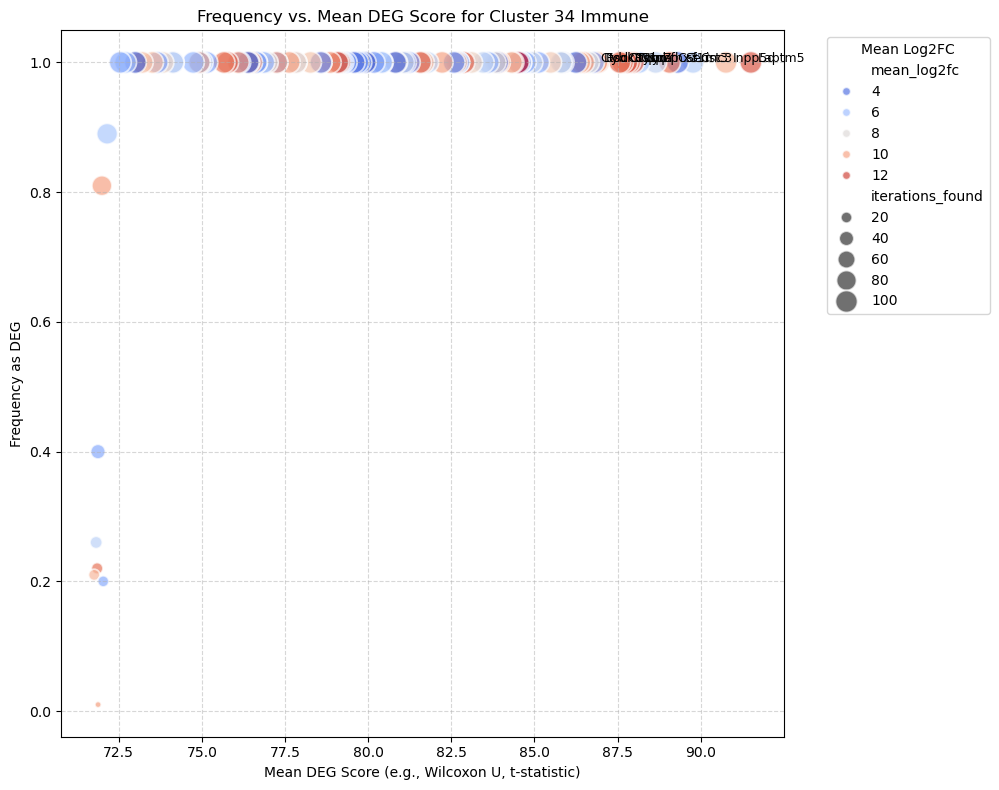


Interpretation for Cluster 34 Immune Frequency vs. Mean Score Scatter Plot:
- Shows relationship between consistency (frequency) and average raw statistical score from DEG tests.
- Ideal genes are in the top-right (high frequency, high mean_score).
- Color indicates average Log2FC, helping distinguish up/down-regulated robust genes.
- Size of points can reflect the number of iterations a gene was found.


In [ ]:
# Define parameters for the robustness analysis
cluster_column_name = 'class'  # The .obs column with your cluster labels
target_cluster_id = "34 Immune"
n_iterations = 100
n_jobs = -1

# Parameters for sc.tl.rank_genes_groups within each subsample
# n_genes: how many top genes to retrieve from each subsample's DEG test
deg_params = {
    'method': 'wilcoxon',
    'n_genes': 100,  # Adjust based on how many DEGs you typically consider
    'pts': True      # Computes fraction of cells expressing gene
}

# --- Step 2: Run the subsampling DEG analysis ---
print(f"\nRunning subsampling DEG analysis for cluster: {target_cluster_id}...")

# Make sure to use a copy of your analysis AnnData object if it's a slice of a larger one
# to avoid SettingWithCopyWarning issues if adata_full.obs[cluster_key] is modified.
robust_degs_df = run_subsampled_deg(
    adata_full=adata.copy(), 
    cluster_key=cluster_column_name,
    groupby=target_cluster_id, # This must be a value from adata_analysis.obs[cluster_column_name]
    subsample_fraction=0.8,
    n_iterations=n_iterations,  # Increase for more robust results (e.g., 50-100), 30 for quicker test
    n_jobs=n_jobs,          # Adjust based on your CPU cores (-1 to use all available)
    rank_genes_groups_params=deg_params
)

print("\nTop robust DEGs found:")
print(robust_degs_df.head())


Visualizing Frequency vs. Mean Score for Cluster 34 Immune...


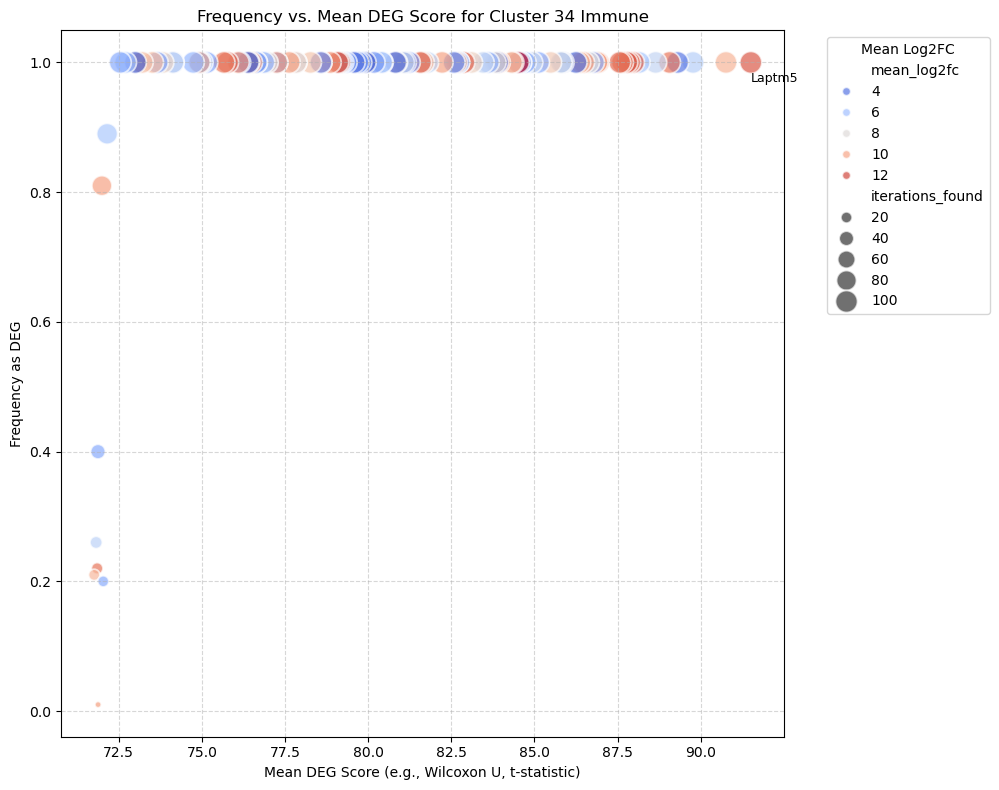


Interpretation for Cluster 34 Immune Frequency vs. Mean Score Scatter Plot:
- Shows relationship between consistency (frequency) and average raw statistical score from DEG tests.
- Ideal genes are in the top-right (high frequency, high mean_score).
- Color indicates average Log2FC, helping distinguish up/down-regulated robust genes.
- Size of points can reflect the number of iterations a gene was found.


In [58]:
# --- Step 3: Visualize the results ---
# Define a descriptive title for your plots
plot_target_info = f"Cluster {target_cluster_id}" 
# If using region: plot_target_info = f"{select_region}, Cluster {target_cluster_id}"
print(f"\nVisualizing Frequency vs. Mean Score for {plot_target_info}...")
plot_frequency_vs_mean_score(
    robust_df=robust_degs_df,
    target_info=plot_target_info,
    highlight_top_n=1,
    label_genes=True
)

In [60]:
# Define parameters for the robustness analysis
cluster_column_name = 'class'  # The .obs column with your cluster labels
target_cluster_id = "06 CTX-CGE GABA"
n_iterations = 100
n_jobs = -1

# Parameters for sc.tl.rank_genes_groups within each subsample
# n_genes: how many top genes to retrieve from each subsample's DEG test
deg_params = {
    'method': 'wilcoxon',
    'n_genes': 100,  # Adjust based on how many DEGs you typically consider
    'pts': True      # Computes fraction of cells expressing gene
}

# --- Step 2: Run the subsampling DEG analysis ---
print(f"\nRunning subsampling DEG analysis for cluster: {target_cluster_id}...")

# Make sure to use a copy of your analysis AnnData object if it's a slice of a larger one
# to avoid SettingWithCopyWarning issues if adata_full.obs[cluster_key] is modified.
robust_degs_df = run_subsampled_deg(
    adata_full=adata.copy(), 
    cluster_key=cluster_column_name,
    groupby=target_cluster_id, # This must be a value from adata_analysis.obs[cluster_column_name]
    subsample_fraction=0.8,
    n_iterations=n_iterations,  # Increase for more robust results (e.g., 50-100), 30 for quicker test
    n_jobs=n_jobs,          # Adjust based on your CPU cores (-1 to use all available)
    rank_genes_groups_params=deg_params
)

print("\nTop robust DEGs found:")
print(robust_degs_df.head())


Running subsampling DEG analysis for cluster: 06 CTX-CGE GABA...


/tmp/ipykernel_846504/1795303150.py:34: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata_full.obs[cluster_key]):


Starting iteration 1/100
Starting iteration 2/100
Starting iteration 3/100
Starting iteration 4/100
Starting iteration 5/100
Starting iteration 6/100
Starting iteration 7/100
Starting iteration 8/100
Starting iteration 9/100
Starting iteration 10/100
Starting iteration 11/100
Starting iteration 12/100
Starting iteration 13/100
Starting iteration 14/100
Starting iteration 15/100
Starting iteration 16/100
Starting iteration 17/100
Starting iteration 18/100
Starting iteration 19/100
Starting iteration 20/100
Starting iteration 21/100
Starting iteration 22/100
Starting iteration 23/100
Starting iteration 24/100
Starting iteration 25/100
Starting iteration 26/100
Starting iteration 27/100
Starting iteration 28/100
Starting iteration 29/100
Starting iteration 30/100
Starting iteration 31/100
Starting iteration 32/100
Starting iteration 33/100
Starting iteration 34/100
Starting iteration 35/100
Starting iteration 36/100
Starting iteration 37/100
Starting iteration 38/100
Starting iteration 39


Visualizing Frequency vs. Mean Score for Cluster 06 CTX-CGE GABA...


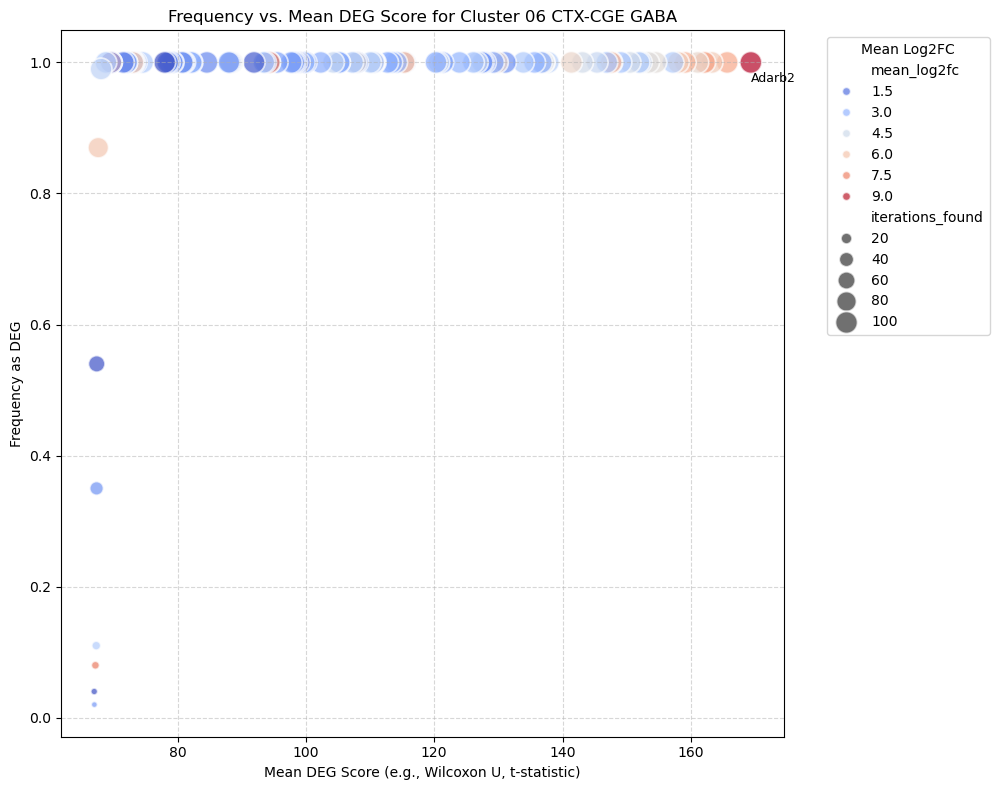


Interpretation for Cluster 06 CTX-CGE GABA Frequency vs. Mean Score Scatter Plot:
- Shows relationship between consistency (frequency) and average raw statistical score from DEG tests.
- Ideal genes are in the top-right (high frequency, high mean_score).
- Color indicates average Log2FC, helping distinguish up/down-regulated robust genes.
- Size of points can reflect the number of iterations a gene was found.


In [61]:
# --- Step 3: Visualize the results ---
# Define a descriptive title for your plots
plot_target_info = f"Cluster {target_cluster_id}" 
# If using region: plot_target_info = f"{select_region}, Cluster {target_cluster_id}"
print(f"\nVisualizing Frequency vs. Mean Score for {plot_target_info}...")
plot_frequency_vs_mean_score(
    robust_df=robust_degs_df,
    target_info=plot_target_info,
    highlight_top_n=1,
    label_genes=True
)